In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Load các file chính
sales = pd.read_csv('dataset/sales.csv')           # Doanh thu theo ngày
sample_submission = pd.read_csv('dataset/sample_submission.csv')
promotions = pd.read_csv('dataset/promotions.csv')
products = pd.read_csv('dataset/products.csv')
web_traffic = pd.read_csv('dataset/web_traffic.csv')
inventory = pd.read_csv('dataset/inventory.csv')
returns = pd.read_csv('dataset/returns.csv')
customers = pd.read_csv('dataset/customers.csv')
order_items = pd.read_csv('dataset/order_items.csv')  # Chi tiết đơn hàng
orders = pd.read_csv('dataset/orders.csv')            # Thông tin đơn hàng
shipments = pd.read_csv('dataset/shipments.csv')
payments = pd.read_csv('dataset/payments.csv')
geography = pd.read_csv('dataset/geography.csv')
reviews = pd.read_csv('dataset/reviews.csv')

print("Dữ liệu đã load thành công!")
print(f"Sales shape: {sales.shape}, Orders: {orders.shape}, Order_Items: {order_items.shape}")

Dữ liệu đã load thành công!
Sales shape: (3833, 3), Orders: (646945, 8), Order_Items: (714669, 7)


In [2]:
# Chuyển Date thành datetime
for df in [sales, sample_submission, web_traffic, orders, shipments]:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    elif 'order_date' in df.columns:
        df['order_date'] = pd.to_datetime(df['order_date'])
    elif 'return_date' in df.columns:
        df['return_date'] = pd.to_datetime(df['return_date'])

# Merge dữ liệu chính
# 1. Merge order_items với orders
orders_full = pd.merge(orders, order_items, on='order_id', how='left')

# 2. Thêm thông tin sản phẩm
orders_full = pd.merge(orders_full, products[['product_id', 'product_name', 'category', 'segment', 'price', 'cogs']], 
                       on='product_id', how='left')

# 3. Thêm thông tin khách hàng
orders_full = pd.merge(orders_full, customers, on='customer_id', how='left')

# 4. Tính Profit
orders_full['profit'] = orders_full['quantity'] * (orders_full['unit_price'] - orders_full.get('cogs', 0))

# 5. Thêm thông tin khuyến mãi nếu có
if 'promo_id' in orders_full.columns:
    orders_full = pd.merge(orders_full, promotions, left_on='promo_id', right_on='promo_id', how='left')

print("Dữ liệu tổng hợp sẵn sàng!")

Dữ liệu tổng hợp sẵn sàng!


In [3]:
# Doanh thu theo tháng/năm
sales['year_month'] = sales['Date'].dt.to_period('M')
monthly_sales = sales.groupby('year_month').agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()
monthly_sales['Profit'] = monthly_sales['Revenue'] - monthly_sales['COGS']
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

fig = px.line(monthly_sales, x='year_month', y=['Revenue', 'Profit'],
              title='Xu hướng Doanh thu và Lợi nhuận theo Tháng',
              labels={'value': 'Giá trị (VND)', 'variable': 'Chỉ số'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

# Doanh thu theo ngày trong tuần / mùa
sales['weekday'] = sales['Date'].dt.day_name()
sales['month'] = sales['Date'].dt.month
daily_pattern = sales.groupby('weekday')['Revenue'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
px.bar(x=daily_pattern.index, y=daily_pattern.values, title='Doanh thu trung bình theo ngày trong tuần').show()

In [4]:
# Merge promo vào orders_full nếu cần
promo_effect = orders_full.groupby('promo_name').agg({
    'order_id': 'nunique',
    'quantity': 'sum',
    'profit': 'sum'
}).reset_index().sort_values('profit', ascending=False)

fig = px.bar(promo_effect.head(10), x='promo_name', y='profit',
             title='Top 10 Khuyến mãi mang lại lợi nhuận cao nhất',
             labels={'profit': 'Lợi nhuận tổng'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

# So sánh doanh thu có/không khuyến mãi
has_promo = orders_full[orders_full['promo_id'].notna()]
no_promo = orders_full[orders_full['promo_id'].isna()]

print(f"Doanh thu từ đơn có khuyến mãi: {has_promo['quantity'].sum() * has_promo['unit_price'].mean():,.0f} VND")
print(f"Doanh thu từ đơn không khuyến mãi: {no_promo['quantity'].sum() * no_promo['unit_price'].mean():,.0f} VND")

Doanh thu từ đơn có khuyến mãi: 5,445,489,479 VND
Doanh thu từ đơn không khuyến mãi: 10,989,068,053 VND


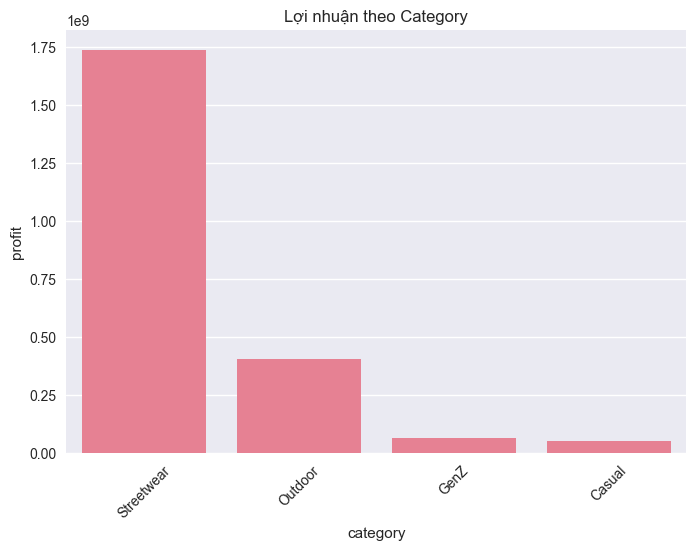

In [5]:
# Top sản phẩm bán chạy
top_products = orders_full.groupby(['product_id', 'product_name', 'category']).agg({
    'quantity': 'sum',
    'profit': 'sum'
}).reset_index().sort_values('quantity', ascending=False)

px.bar(top_products.head(15), x='product_name', y='quantity', color='category',
       title='Top 15 Sản phẩm bán chạy nhất').update_layout(xaxis_tickangle=-45).show()

# Profit margin theo category
category_margin = orders_full.groupby('category').agg({
    'profit': 'sum',
    'quantity': 'sum'
}).reset_index()
category_margin['avg_margin'] = category_margin['profit'] / (category_margin['quantity'] * orders_full['unit_price'].mean())

sns.barplot(data=category_margin.sort_values('profit', ascending=False), x='category', y='profit')
plt.title('Lợi nhuận theo Category')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Phân bố khách hàng theo Region (từ geography)
customer_geo = pd.merge(customers, geography, on='zip', how='left')
region_sales = customer_geo.groupby('region').size().reset_index(name='customer_count')

px.pie(region_sales, names='region', values='customer_count', 
       title='Phân bố Khách hàng theo Khu vực').show()

# Retention / Signup theo thời gian
customers['signup_year'] = pd.to_datetime(customers['signup_date']).dt.year
signup_trend = customers.groupby('signup_year').size()
px.line(x=signup_trend.index, y=signup_trend.values, title='Số lượng khách hàng đăng ký theo năm').show()

In [7]:
# Stockout rate
inventory['stockout_rate'] = inventory['stockout_days'] / 30  # giả sử tháng 30 ngày
px.histogram(inventory, x='stockout_rate', title='Tỷ lệ Stockout').show()

# Return rate
return_rate = returns.groupby('return_reason')['return_quantity'].sum().reset_index()
px.bar(return_rate, x='return_reason', y='return_quantity', 
       title='Lý do trả hàng phổ biến').show()

# Shipping performance
shipments['delivery_time'] = (pd.to_datetime(shipments['delivery_date']) - 
                              pd.to_datetime(shipments['ship_date'])).dt.days
px.box(shipments, y='delivery_time', title='Thời gian giao hàng').show()

In [8]:
# Traffic theo nguồn
traffic_source = web_traffic.groupby('traffic_source')['sessions'].sum().reset_index()
px.bar(traffic_source, x='traffic_source', y='sessions', title='Traffic theo Nguồn').show()

# Bounce rate & avg session duration theo thời gian
web_traffic['Date'] = pd.to_datetime(web_traffic['date'])
monthly_traffic = web_traffic.groupby(web_traffic['Date'].dt.to_period('M')).agg({
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean'
}).reset_index()